In [1]:
from pathlib import Path
import json
import torch

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

# Existing split manifest.
# Validation and test samples will later be merged
# and re-split using StratifiedKFold.

MANIFEST_PATH = (
    REPO_ROOT
    / "reports"
    / "manifests"
    / "broach_dataset_split_seed42.csv"
)

DATA_ROOT = REPO_ROOT / "data/03_broach_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports" 
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = REPO_ROOT / "models" / "ae_bn16_broach_dataset_PyTorch_20260709.pth"

SCORES_PATH = OUTPUT_DIR / "SVE" / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "SVE" / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "SVE" / "ae_metrics.csv"

val_df = pd.read_csv(OUTPUT_DIR / "val_scores_with_baselines.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test_scores_with_baselines.csv")

In [3]:
def load_data_from_manifest(
    data_root: Path,
    manifest_csv: Path,
    split: str,
    target_size=(150, 100)
):
    df = pd.read_csv(manifest_csv)
    df_split = df[df["split"] == split].reset_index(drop=True)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        filename = str(row["filename"])
        label = int(row["label"])

        folder = data_root / (
            "test" if split in ["test", "validation"] else "train"
        )

        file_path = folder / filename

        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue

        img = (
            Image.open(file_path)
            .convert("RGB")
            .resize(target_size)
        )

        img = np.asarray(img, dtype=np.float32) / 255.0

        images.append(img)
        labels.append(label)
        filenames.append(filename)

    return (
        np.array(images),
        np.array(labels),
        np.array(filenames)
    )

class Autoencoder(torch.nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=2, stride=2),

            torch.nn.Conv2d(4, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.MaxPool2d(kernel_size=(2, 3), stride=(2, 3)),

            torch.nn.Conv2d(8, 12, kernel_size=3, padding=1),
            torch.nn.ReLU()
        )

        self.flatten = torch.nn.Flatten()

        self.encoder_fc = torch.nn.Sequential(
            torch.nn.Linear(12 * 25 * 25, 16),
            torch.nn.ReLU()
        )

        # Decoder
        self.decoder_fc = torch.nn.Sequential(
            torch.nn.Linear(16, 12 * 25 * 25),
            torch.nn.ReLU()
        )

        self.decoder_conv = torch.nn.Sequential(
            torch.nn.Conv2d(12, 12, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 3), mode='nearest'),

            torch.nn.Conv2d(12, 8, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Upsample(scale_factor=(2, 2), mode='nearest'),

            torch.nn.Conv2d(8, 4, kernel_size=3, padding=1),
            torch.nn.ReLU(),

            torch.nn.Conv2d(4, 3, kernel_size=3, padding=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder_conv(x)

        x = self.flatten(x)

        latent = self.encoder_fc(x)

        x = self.decoder_fc(latent)

        x = x.view(-1, 12, 25, 25)

        x = self.decoder_conv(x)

        return x

## Load data and reconstruct images 

In [4]:
# Load model
model = Autoencoder()

state_dict = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state_dict)

model.eval()

Autoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 3), stride=(2, 3), padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(8, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_fc): Sequential(
    (0): Linear(in_features=7500, out_features=16, bias=True)
    (1): ReLU()
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=16, out_features=7500, bias=True)
    (1): ReLU()
  )
  (decoder_conv): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Upsample(scale_factor=(2.0, 3.0), mode='nearest')
    (3): Conv2d(12, 8, kernel_size=(3, 3), stride=(1, 1), pad

In [5]:
# Load images

X_val, y_val, f_val = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "validation",
    IMAGE_SIZE
)

X_test, y_test, f_test = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "test",
    IMAGE_SIZE
)

100%|██████████| 2500/2500 [01:35<00:00, 26.19it/s] 


## Generate Error maps 

In [6]:
def compute_error_maps(model, images, batch_size=32):

    images_torch = (
        torch.from_numpy(images)
        .permute(0, 3, 1, 2)  # NHWC -> NCHW
        .float()
    )

    model.eval()
    recon_batches = []

    with torch.no_grad():
        for start in range(0, len(images_torch), batch_size):
            batch = images_torch[start:start + batch_size]

            recon = model(batch)

            recon_batches.append(
                recon.permute(0, 2, 3, 1).cpu().numpy()
            )

    recon = np.concatenate(recon_batches, axis=0)

    return (images - recon) ** 2


print("Computing error maps...")

val_error = compute_error_maps(model, X_val)
test_error = compute_error_maps(model, X_test)

# --------------------------------------------------
# Pool validation and test data for Nested CV
# --------------------------------------------------

all_error = np.concatenate(
    [val_error, test_error],
    axis=0
)

all_y = np.concatenate(
    [y_val, y_test],
    axis=0
)

all_filenames = np.concatenate(
    [f_val, f_test],
    axis=0
)

print("Combined dataset")
print("Samples :", len(all_y))
print("Normals :", np.sum(all_y == 0))
print("Anomaly :", np.sum(all_y == 1))

Computing error maps...
Combined dataset
Samples : 5000
Normals : 4955
Anomaly : 45


## SVE flexible 
Sweeping Segment and top k amount to analyze detection behaviour.

In [7]:
def compute_sve_scores(error_map, n_segments, top_k):

    width = error_map.shape[2]
    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segments = []
    for l, r in zip(boundaries[:-1], boundaries[1:]):
        if r <= l:
            continue
        segments.append(
            error_map[:, :, l:r, :].mean(axis=(1,2,3))
        )

    segments = np.stack(segments, axis=1)
    sve_max = segments.max(axis=1)
    top_k = min(top_k, segments.shape[1])
    sve_topk = np.sort(segments, axis=1)[:, -top_k:].mean(axis=1)

    return sve_max, sve_topk

### Threshold & Evaluation function 


In [8]:
def select_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return float(np.max(scores))
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx])


def evaluate(y_true, scores, threshold):
    y_pred = (scores >= threshold).astype(int)
    return {
        "pr_auc": average_precision_score(y_true, scores),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }

## Nested 5-Fold Group Validation 

5x5 Nested Cross Validation \
Outer folds = test set sensitivity analysis \
Inner folds = SVE parameter optimization

Dataset contains 5000 total samples (4955 normal cycles and 45 anomalies).

StratiefiedFold generates a identical distribution for the classes.

In [9]:
segment_list = list(range(1, 16))
topk_list = list(range(1, 4))

OUTER_SPLITS = 5
INNER_SPLITS = 5

outer_cv = RepeatedStratifiedKFold(
    n_splits=OUTER_SPLITS,
    n_repeats=3,
    random_state=42
)

inner_cv = RepeatedStratifiedKFold(
    n_splits=INNER_SPLITS,
    n_repeats=3,
    random_state=42
)

nested_results = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(all_error, all_y),
    start=1
):
    print(
        f"Fold {fold}: "
        f"train={len(train_idx)}, "
        f"test={len(test_idx)}"
    )


Fold 1: train=4000, test=1000
Fold 2: train=4000, test=1000
Fold 3: train=4000, test=1000
Fold 4: train=4000, test=1000
Fold 5: train=4000, test=1000
Fold 6: train=4000, test=1000
Fold 7: train=4000, test=1000
Fold 8: train=4000, test=1000
Fold 9: train=4000, test=1000
Fold 10: train=4000, test=1000
Fold 11: train=4000, test=1000
Fold 12: train=4000, test=1000
Fold 13: train=4000, test=1000
Fold 14: train=4000, test=1000
Fold 15: train=4000, test=1000


In [10]:
# ------------------------------------------------------------------
# Outer cross validation loop
# ------------------------------------------------------------------

for outer_fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(all_error, all_y),
    start=1
):

    print(f"\nOuter Fold {outer_fold}")

    X_inner = all_error[train_idx]
    y_inner = all_y[train_idx]

    X_outer_test = all_error[test_idx]
    y_outer_test = all_y[test_idx]

    print("Inner pool :", len(y_inner))
    print("Outer test :", len(y_outer_test))

    print(
        "Inner anomalies:",
        np.sum(y_inner == 1)
    )

    print(
        "Outer anomalies:",
        np.sum(y_outer_test == 1)
    )


Outer Fold 1
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 2
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 3
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 4
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 5
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 6
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 7
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 8
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 9
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 10
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 11
Inner pool : 4000
Outer test : 1000
Inner anomalies: 36
Outer anomalies: 9

Outer Fold 12
Inne

In [11]:
# ------------------------------------------------------------------
# Nested CV - Hyperparameter optimization and evaluation
# ------------------------------------------------------------------

nested_results = []
segment_results = []
fold_f1s = []

for outer_fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(all_error, all_y),
    start=1
):

    print(f"\nOuter Fold {outer_fold}")

    X_inner = all_error[train_idx]
    y_inner = all_y[train_idx]

    X_outer_test = all_error[test_idx]
    y_outer_test = all_y[test_idx]

    config_results = []

    # --------------------------------------------------------------
    # Inner CV: Hyperparameter search
    # --------------------------------------------------------------

    for n_segments in segment_list:
        for top_k in topk_list:

            fold_pr_aucs = []

            for inner_train_idx, inner_val_idx in inner_cv.split(
                X_inner,
                y_inner
            ):

                X_inner_train = X_inner[inner_train_idx]
                y_inner_train = y_inner[inner_train_idx]

                X_inner_val = X_inner[inner_val_idx]
                y_inner_val = y_inner[inner_val_idx]

                # Training fold scores
                _, train_scores = compute_sve_scores(
                    X_inner_train,
                    n_segments,
                    top_k
                )

                threshold = select_best_f1_threshold(
                    y_inner_train,
                    train_scores
                )

                # Validation fold scores
                _, val_scores = compute_sve_scores(
                    X_inner_val,
                    n_segments,
                    top_k
                )

                metrics = evaluate(
                    y_inner_val,
                    val_scores,
                    threshold
                )

                fold_pr_aucs.append(
                    metrics["pr_auc"]
                )

                fold_f1s.append(
                    metrics["f1"]
                )

            config_results.append({
                "segments": n_segments,
                "top_k": top_k,
                "mean_pr_auc": np.mean(fold_pr_aucs)
            })

            segment_results.append({
                "outer_fold": outer_fold,
                "segments": n_segments,
                "top_k": top_k,
                "pr_auc": np.mean(fold_pr_aucs),
                "f1": np.mean(fold_f1s)
            })


    config_df = pd.DataFrame(config_results)

    best_config = config_df.loc[
        config_df["mean_pr_auc"].idxmax()
    ]

    best_segments = int(best_config["segments"])
    best_topk = int(best_config["top_k"])

    print(
        f"Best config: "
        f"segments={best_segments}, "
        f"top_k={best_topk}, "
        f"PR-AUC={best_config['mean_pr_auc']:.4f}"
    )

    # --------------------------------------------------------------
    # Refit threshold on complete inner pool
    # --------------------------------------------------------------

    _, inner_scores = compute_sve_scores(
        X_inner,
        best_segments,
        best_topk
    )

    best_threshold = select_best_f1_threshold(
        y_inner,
        inner_scores
    )

    # --------------------------------------------------------------
    # Evaluate on outer test fold
    # --------------------------------------------------------------

    _, outer_scores = compute_sve_scores(
        X_outer_test,
        best_segments,
        best_topk
    )

    outer_metrics = evaluate(
        y_outer_test,
        outer_scores,
        best_threshold
    )

    print(
        f"Outer Test  -> "
        f"PR-AUC={outer_metrics['pr_auc']:.4f}, "
        f"F1={outer_metrics['f1']:.4f}"
    )

    nested_results.append({
        "fold": outer_fold,
        "segments": best_segments,
        "top_k": best_topk,
        "threshold": best_threshold,
        "pr_auc": outer_metrics["pr_auc"],
        "f1": outer_metrics["f1"],
        "precision": outer_metrics["precision"],
        "recall": outer_metrics["recall"]
    })


Outer Fold 1
Best config: segments=5, top_k=1, PR-AUC=0.9398
Outer Test  -> PR-AUC=0.7941, F1=0.7368

Outer Fold 2
Best config: segments=6, top_k=1, PR-AUC=0.9218
Outer Test  -> PR-AUC=0.9103, F1=0.8889

Outer Fold 3
Best config: segments=7, top_k=1, PR-AUC=0.9183
Outer Test  -> PR-AUC=0.9889, F1=0.9474

Outer Fold 4
Best config: segments=3, top_k=1, PR-AUC=0.9391
Outer Test  -> PR-AUC=0.7042, F1=0.6316

Outer Fold 5
Best config: segments=7, top_k=1, PR-AUC=0.9306
Outer Test  -> PR-AUC=0.9301, F1=0.8571

Outer Fold 6
Best config: segments=7, top_k=1, PR-AUC=0.9415
Outer Test  -> PR-AUC=0.8279, F1=0.7368

Outer Fold 7
Best config: segments=7, top_k=1, PR-AUC=0.9197
Outer Test  -> PR-AUC=0.9889, F1=0.9474

Outer Fold 8
Best config: segments=6, top_k=1, PR-AUC=0.9323
Outer Test  -> PR-AUC=0.8836, F1=0.7059

Outer Fold 9
Best config: segments=9, top_k=1, PR-AUC=0.9192
Outer Test  -> PR-AUC=0.9061, F1=0.8889

Outer Fold 10
Best config: segments=9, top_k=1, PR-AUC=0.9339
Outer Test  -> PR-A

In [12]:
nested_results_df = pd.DataFrame(nested_results)

nested_results_df

nested_results_df[
    ["pr_auc", "f1", "precision", "recall"]
].agg(["mean", "std", "min", "max"])

,pr_auc,f1,precision,recall
mean,0.896953,0.839225,0.825185,0.866667
std,0.080432,0.094154,0.124295,0.120258
min,0.704226,0.631579,0.600000,0.666667
max,0.988889,0.947368,1.000000,1.000000


In [13]:
segment_results_df = pd.DataFrame(segment_results)
segment_results_df.head()

,outer_fold,segments,top_k,pr_auc,f1
0,1,1,1,0.666883,0.701453
1,1,1,2,0.666883,0.701453
2,1,1,3,0.666883,0.701453
3,1,2,1,0.777281,0.715561
4,1,2,2,0.666883,0.712739


# Save results 

In [14]:
# ------------------------------------------------------------------
# Save nested CV fold results
# ------------------------------------------------------------------

nested_results_df.to_csv(
    OUTPUT_DIR / "SVE" / "nested_cv_results.csv",
    index=False
)

nested_results_df[
    ["pr_auc", "f1", "precision", "recall"]
].agg(
    ["mean", "std", "min", "max"]
).to_csv(
    OUTPUT_DIR / "SVE" / "nested_cv_summary.csv"
)

# --------------------------------------------------------------
# Save parameter sensitivity results
# --------------------------------------------------------------

segment_results_df.to_csv(
    OUTPUT_DIR / "SVE" / "nested_cv_parameter_sensitivity.csv",
    index=False
)

print("Saved:")
print(OUTPUT_DIR / "SVE" / "nested_cv_results.csv")
print(OUTPUT_DIR / "SVE" / "nested_cv_summary.csv")
print(OUTPUT_DIR / "SVE" / "nested_cv_parameter_sensitivity.csv")

Saved:
C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\SVE\nested_cv_results.csv
C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\SVE\nested_cv_summary.csv
C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\SVE\nested_cv_parameter_sensitivity.csv


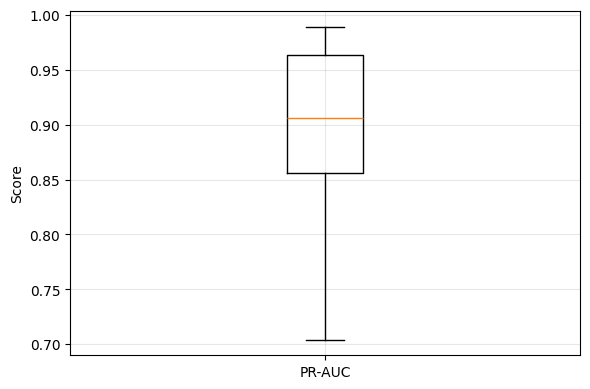

In [15]:
plt.figure(figsize=(6, 4))

plt.boxplot(
    nested_results_df["pr_auc"],
    tick_labels=["PR-AUC"]
)

plt.ylabel("Score")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SVE" / "nested_cv_pr_auc_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### PLot Results 

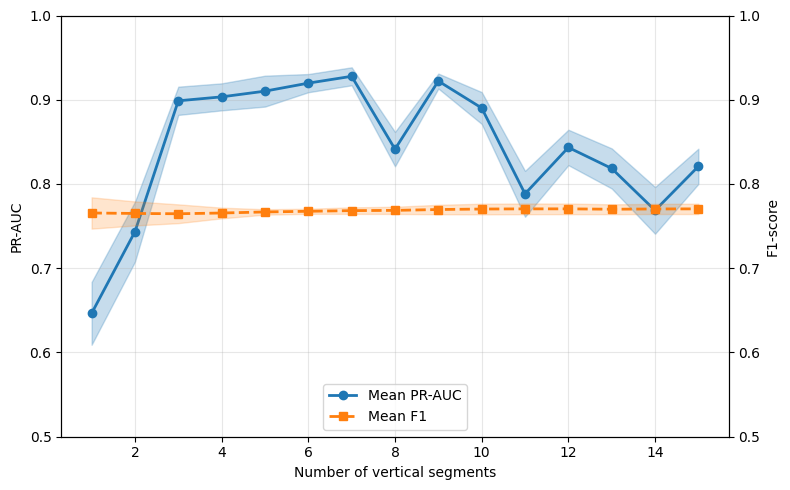

In [20]:
# --------------------------------------------------------------
# Sensitivity analysis across all CV runs
# --------------------------------------------------------------

plot_df = (
    segment_results_df[
        segment_results_df["top_k"] == 1
    ]
    .groupby("segments")
    .agg(
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 5))

# --------------------------------------------------------------
# PR-AUC
# --------------------------------------------------------------

line1 = ax1.plot(
    plot_df["segments"],
    plot_df["pr_auc_mean"],
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="Mean PR-AUC"
)

ax1.fill_between(
    plot_df["segments"],
    plot_df["pr_auc_mean"] - plot_df["pr_auc_std"],
    plot_df["pr_auc_mean"] + plot_df["pr_auc_std"],
    alpha=0.25,
    color="tab:blue",
)

ax1.set_xlabel("Number of vertical segments")
ax1.set_ylabel("PR-AUC")
ax1.set_ylim(0.5, 1.0)

# --------------------------------------------------------------
# F1
# --------------------------------------------------------------

ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df["segments"],
    plot_df["f1_mean"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="tab:orange",
    label="Mean F1"
)

ax2.fill_between(
    plot_df["segments"],
    plot_df["f1_mean"] - plot_df["f1_std"],
    plot_df["f1_mean"] + plot_df["f1_std"],
    alpha=0.20,
    color="tab:orange",
)

ax2.set_ylabel("F1-score")
ax2.set_ylim(0.5, 1.0)

# --------------------------------------------------------------
# Legend
# --------------------------------------------------------------

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc="lower center"
)

ax1.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SVE" / "nested_cv_sensitivity_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plot_df.to_csv(
    OUTPUT_DIR / "SVE" / "nested_cv_parameter_sensitivity_summary.csv",
    index=False
)

plt.show()

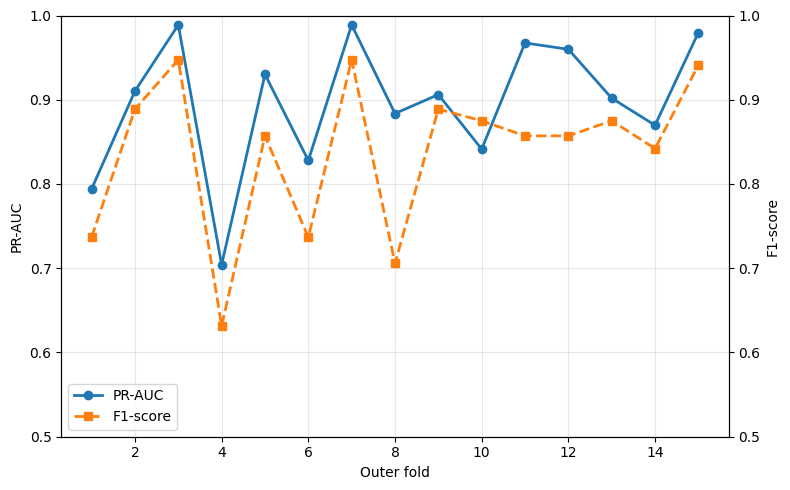

In [ ]:
# --------------------------------------------------------------
# Outer fold performance
# --------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(8, 5))

# PR-AUC
line1 = ax1.plot(
    nested_results_df["fold"],
    nested_results_df["pr_auc"],
    marker="o",
    linewidth=2,
    color="tab:blue",
    label="PR-AUC"
)

ax1.set_xlabel("Outer fold")
ax1.set_ylabel("PR-AUC")
ax1.set_ylim(0.5, 1.0)

# F1
ax2 = ax1.twinx()

line2 = ax2.plot(
    nested_results_df["fold"],
    nested_results_df["f1"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="tab:orange",
    label="F1-score"
)

ax2.set_ylabel("F1-score")
ax2.set_ylim(0.5, 1.0)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc="lower left"
)

ax1.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SVE" / "nested_cv_outer_fold_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 


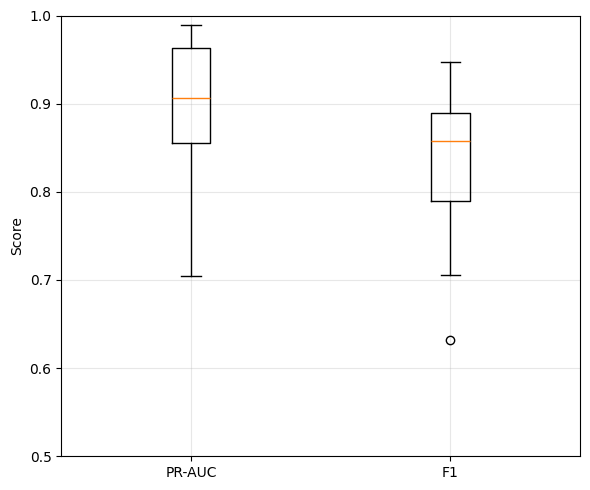

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.boxplot(
    [
        nested_results_df["pr_auc"],
        nested_results_df["f1"]
    ],
    tick_labels=["PR-AUC", "F1"]
)

ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.0)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "SVE" / "nested_cv_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
plot_df.to_csv(
    OUTPUT_DIR / "SVE" / "nested_cv_pr_auc_by_segments.csv",
    index=False
)